# Intro to Machine Learning for Clinical Data - Master Notebook

**Dataset:** Breast Cancer Wisconsin (Diagnostic): 569 patients, 30 features derived from digitised fine needle aspirate (FNA) biopsy images.

This notebook runs top to bottom in Google Colab with no installation required.

In [1]:
# Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

sns.set_style("whitegrid")
# %matplotlib inline

## Data Wrangling
### Loading the data

In [2]:
# Load the dataset and view it as a DataFrame
data = load_breast_cancer()

df = pd.DataFrame(data.data, columns=data.feature_names)
df['diagnosis'] = data.target                                    # 0 = malignant, 1 = benign
df['diagnosis_label'] = df['diagnosis'].map({0: 'Malignant', 1: 'Benign'})

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis,diagnosis_label
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,Malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,Malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,Malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,Malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,Malignant


In [3]:
# Basic shape and balance check
print(f"Patients: {df.shape[0]}, Features: {df.shape[1] - 2}")
df['diagnosis_label'].value_counts()

Patients: 569, Features: 30


,count
diagnosis_label,
Benign,357
Malignant,212


### Exploratory Data Analysis (EDA)

Using a subset of five features (rather than all 30) so the pairplot stays readable.

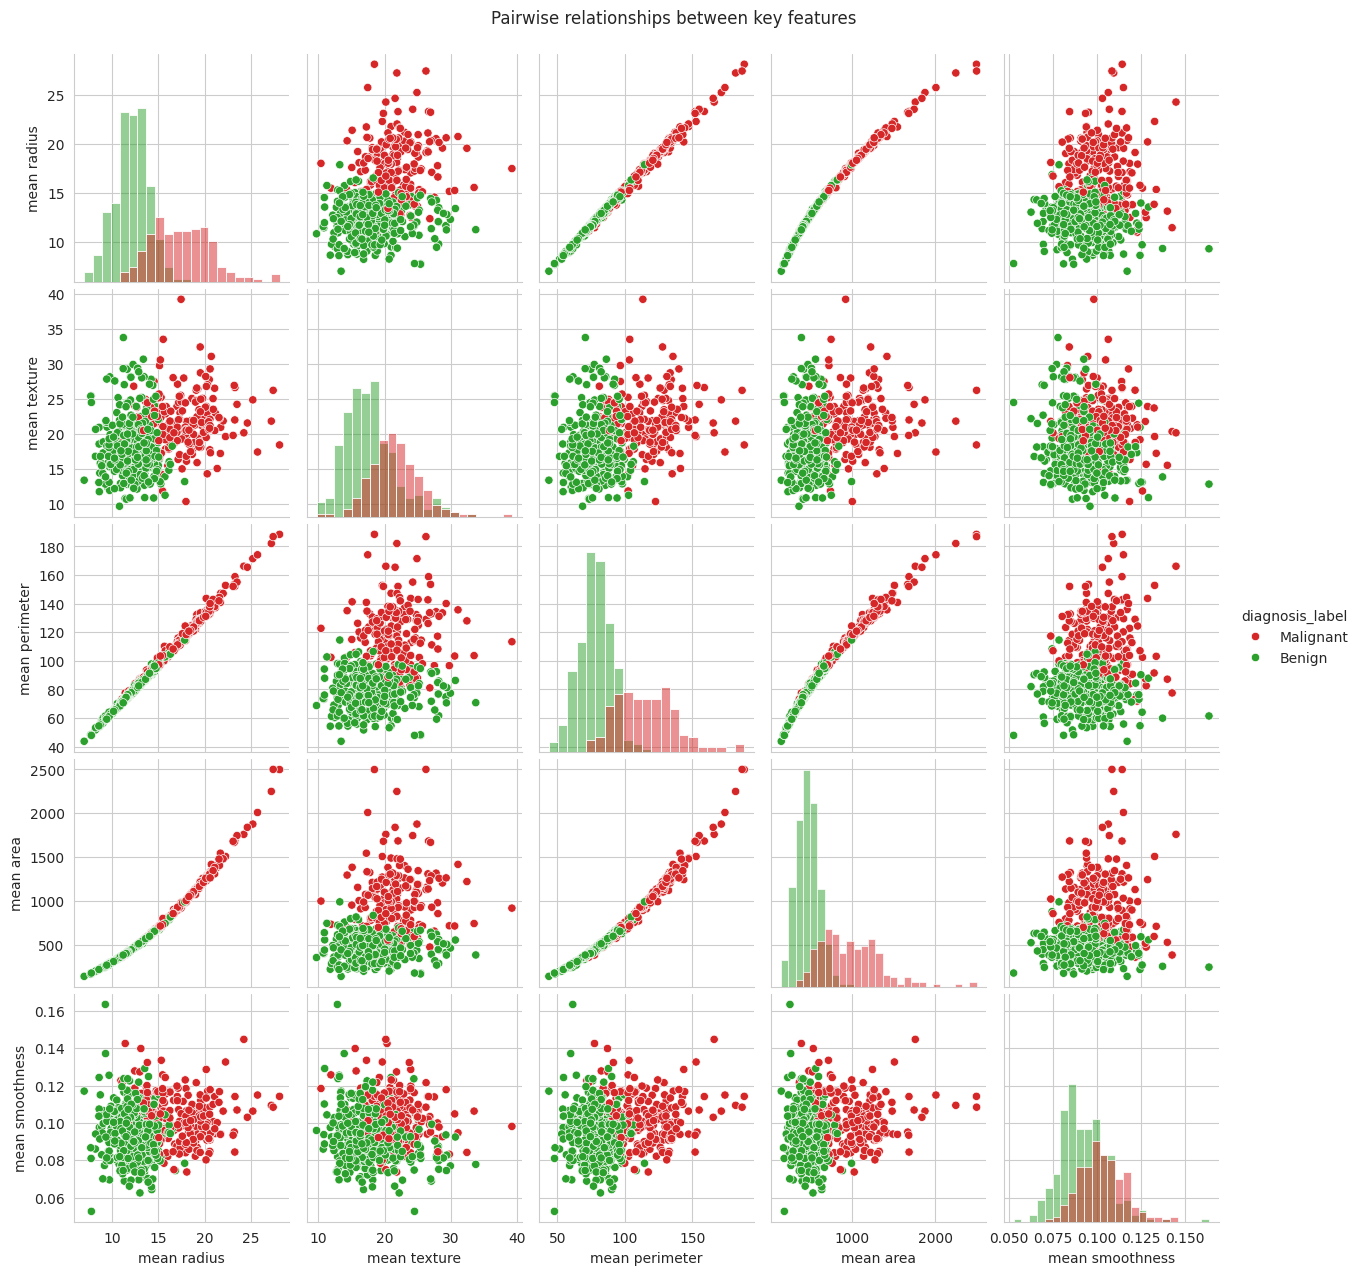

In [4]:
# Pairwise relationships, colored by diagnosis
eda_features = ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness']

g = sns.pairplot(
    df, vars=eda_features, hue='diagnosis_label',
    palette={'Malignant': '#d62728', 'Benign': '#2ca02c'}, diag_kind='hist'
)
g.figure.suptitle('Pairwise relationships between key features', y=1.02)
plt.show()

### Train/Test Split

Holding back 30% of patients that the model never sees during training, for an honest final check.

In [5]:
X = df[list(data.feature_names)]   # all 30 original features
y = df['diagnosis']                # 0 = malignant, 1 = benign

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} patients")
print(f"Test set:     {X_test.shape[0]} patients")

Training set: 398 patients
Test set:     171 patients


## Scaling & PCA
### The Scale Problem

In [6]:
# Look at the range of a few features — notice how different the scales are
X_train.describe().T[['mean', 'std', 'min', 'max']].loc[
    ['mean area', 'mean smoothness', 'mean radius', 'mean symmetry']
]

,mean,std,min,max
mean area,650.784171,340.295183,143.50000,2010.0000
mean smoothness,0.095789,0.013349,0.06251,0.1425
mean radius,14.093847,3.489558,6.98100,25.7300
mean symmetry,0.180493,0.028055,0.10600,0.3040


### Applying `StandardScaler`

Rescales every feature to the same footing (mean 0, comparable spread) so no feature dominates purely because of its units.

In [7]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)   # fit only on training data
X_test_scaled = scaler.transform(X_test)         # apply the same transform to test data

# Confirm the effect: every feature now has mean ~0 and std ~1
pd.DataFrame(X_train_scaled, columns=X_train.columns).describe().T[['mean', 'std']].head()

,mean,std
mean radius,-4.994330e-15,1.001259
mean texture,2.733715e-15,1.001259
mean perimeter,2.048613e-15,1.001259
mean area,1.394753e-15,1.001259
mean smoothness,4.334891e-15,1.001259


### Principal Component Analysis (PCA)

Compressing 30 features down to the 2 combinations that preserve the most variation.

In [8]:
pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)

print(f"Variance explained by PC1: {pca.explained_variance_ratio_[0]:.1%}")
print(f"Variance explained by PC2: {pca.explained_variance_ratio_[1]:.1%}")
print(f"Total variance captured in 2D: {pca.explained_variance_ratio_.sum():.1%}")

Variance explained by PC1: 45.2%
Variance explained by PC2: 19.6%
Total variance captured in 2D: 64.8%


### Visualizing the Clusters

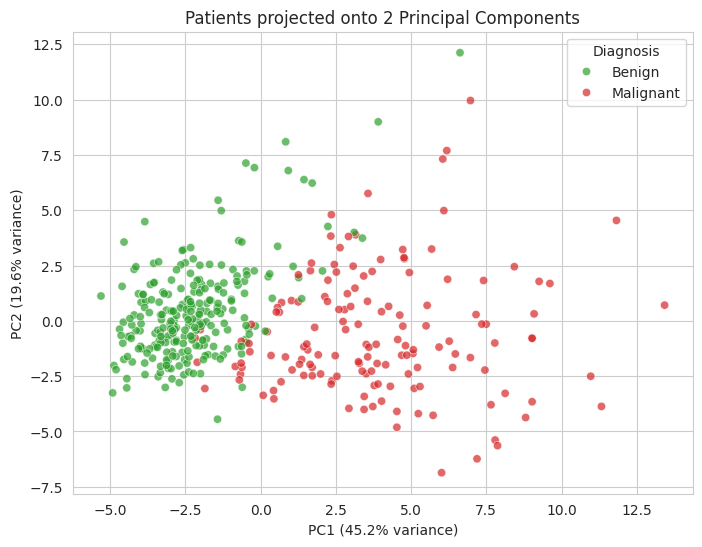

In [9]:
pca_df = pd.DataFrame(X_train_pca, columns=['PC1', 'PC2'])
pca_df['diagnosis_label'] = y_train.map({0: 'Malignant', 1: 'Benign'}).values

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=pca_df, x='PC1', y='PC2', hue='diagnosis_label',
    palette={'Malignant': '#d62728', 'Benign': '#2ca02c'}, alpha=0.7
)
plt.title('Patients projected onto 2 Principal Components')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.legend(title='Diagnosis')
plt.show()

## Modeling, Evaluation & Biological Interpretation
### Training the Random Forest

Note: tree-based models don't require feature scaling. We reuse the scaled data here purely to keep the pipeline consistent.

In [10]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

print("Model trained on", X_train_scaled.shape[0], "patients.")

Model trained on 398 patients.


### Evaluating — Confusion Matrix

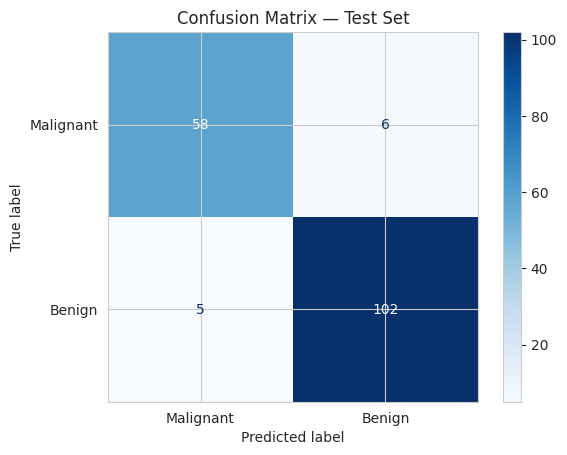

In [11]:
y_pred = rf_model.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred, labels=[0, 1])  # 0 = Malignant, 1 = Benign

disp = ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, labels=[0, 1],
    display_labels=['Malignant', 'Benign'], cmap='Blues'
)
plt.title('Confusion Matrix — Test Set')
plt.show()

### Sensitivity & Specificity

Treating Malignant as the "positive" (disease-present) class.

In [12]:
tp, fn, fp, tn = cm[0, 0], cm[0, 1], cm[1, 0], cm[1, 1]

sensitivity = tp / (tp + fn)   # Of all actual malignant cases, how many did we catch?
specificity = tn / (tn + fp)   # Of all actual benign cases, how many did we correctly clear?

print(f"Sensitivity (catching malignant cases):        {sensitivity:.1%}")
print(f"Specificity (correctly clearing benign cases):  {specificity:.1%}")
print()
print(classification_report(y_test, y_pred, target_names=['Malignant', 'Benign']))

Sensitivity (catching malignant cases):        90.6%
Specificity (correctly clearing benign cases):  95.3%

              precision    recall  f1-score   support

   Malignant       0.92      0.91      0.91        64
      Benign       0.94      0.95      0.95       107

    accuracy                           0.94       171
   macro avg       0.93      0.93      0.93       171
weighted avg       0.94      0.94      0.94       171



### Feature Importance

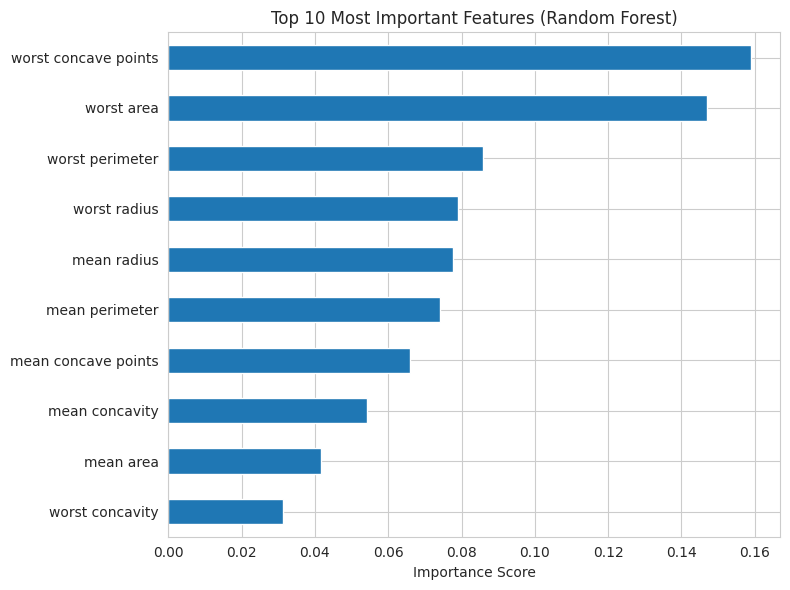

In [13]:
importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
top_features = importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 6))
top_features.sort_values().plot(kind='barh', color='#1f77b4')
plt.title('Top 10 Most Important Features (Random Forest)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

### Wrap-up

**Pipeline recap:** load data → explore (X and y) → split → scale → reduce dimensions to visualize structure → train a model → evaluate honestly on unseen data → interpret which features drove the decision.

Keep this notebook as a reference. The goal of the workshop was conceptual fluency with the workflow, not code recall.